In [45]:
import pandas as pd
import numpy as np
from matplotlib import dates
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'NanumGothic'

data = pd.read_csv('nei_1_1_0.csv')
data['REG_DTIME'] = pd.to_datetime(data['REG_DTIME'])
data['year'] = data['REG_DTIME'].dt.year
data['month'] = data['REG_DTIME'].dt.month
data['day'] = data['REG_DTIME'].dt.day

In [46]:
def year_df_sum(df , year):
    df = df[df['year'] == year] 
    arg_df = df.groupby(['year','month','day', 'h_dong']).sum()
    arg_df = arg_df.reset_index(level=['year','month','day','h_dong'])
    return arg_df

def year_df_mean(df , year):
    df = df[df['year'] == year] 
    arg_df = df.groupby(['year','month','day', 'h_dong']).mean()
    arg_df = arg_df.reset_index(level=['year','month','day','h_dong'])
    return arg_df

def year_df_max(df , year):
    df = df[df['year'] == year] 
    arg_df = df.groupby(['year','month','day', 'h_dong']).max()
    arg_df = arg_df.reset_index(level=['year','month','day','h_dong'])
    return arg_df

In [47]:
def get_col_heatmap(arg_df, col,year):
    heat_df = pd.DataFrame()

    for dong in data['h_dong'].unique():
        heat_df[dong] = arg_df[arg_df['h_dong'] == dong][col].to_list()
    dt = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    
    if len(heat_df.index) != len(dt):
        heat_df = heat_df[:-1]
    heat_df.index = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    

    fig = plt.figure(figsize=(25, 40))
    gs = gridspec.GridSpec(nrows=4, # row 몇 개 
                           ncols=1, # col 몇 개 
                           height_ratios=[1,1,1,1], 
                           width_ratios=[1])
    gs.update(wspace=0.1, hspace=0.4)
    
    for i in range(4):
        ax = plt.subplot(gs[i,0])
        heat_s = heat_df[i*90 : (i+1)*90].T
        ax.set_title(f' {col} columns heatmap  {str(heat_s.columns[0])[:-8]} ~ {str(heat_s.columns[-1])[:-8]}' , fontsize = 20)
        ax.set_yticks(range(len(heat_s.index)),heat_s.index , fontsize = 10)
        ax.set_xticks(range(len(heat_s.columns)),heat_s.columns , fontsize = 10,rotation=45 )
        
        cb = ax.pcolor(heat_s , cmap=matplotlib.cm.Blues)
        plt.colorbar(cb)
        


In [48]:
def get_col_heatmap_test(arg_df, col,year):
    heat_df = pd.DataFrame()

    for dong in data['h_dong'].unique():
        heat_df[dong] = arg_df[arg_df['h_dong'] == dong][col].to_list()
    dt = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    
    if len(heat_df.index) != len(dt):
        heat_df = heat_df[:-1]
    heat_df.index = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    

    fig = plt.figure(figsize=(25, 40))
    gs = gridspec.GridSpec(nrows=4, # row 몇 개 
                           ncols=1, # col 몇 개 
                           height_ratios=[1,1,1,1], 
                           width_ratios=[1])
    gs.update(wspace=0.1, hspace=0.4)
    
    for i in range(1):
        ax = plt.subplot(gs[i,0])
        heat_s = heat_df[i*90 : (i+1)*90].T
        ax.set_title(f' {col} columns heatmap  {str(heat_s.columns[0])[:-8]} ~ {str(heat_s.columns[-1])[:-8]}' , fontsize = 20)
        ax.set_yticks(range(len(heat_s.index)),heat_s.index , fontsize = 10)
        ax.set_xticks(range(len(heat_s.columns)),heat_s.columns , fontsize = 10,rotation=45 )
        
        cb = ax.pcolor(heat_s , cmap=matplotlib.cm.Blues)
        plt.colorbar(cb)
        
        
def get_col_scatter(arg_df, dong , year):
    count_df = pd.DataFrame()
    nei_df = pd.DataFrame()
    
    count_df[dong] = arg_df[arg_df['h_dong'] == dong]['count'].to_list()
    nei_df[dong] = arg_df[arg_df['h_dong'] == dong]['nei1'].to_list()

    dt = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    
    if len(count_df.index) != len(dt):
        count_df = count_df[:-1]
        nei_df = nei_df[:-1]
    
    count_df.index = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    nei_df.index = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    
    
    fig = plt.figure(figsize=(25, 40))
    gs = gridspec.GridSpec(nrows=4, # row 몇 개 
                           ncols=1, # col 몇 개 
                           height_ratios=[1,1,1,1], 
                           width_ratios=[1])
    gs.update(wspace=0.1, hspace=0.4)
    
    for i in range(4):
        ax = plt.subplot(gs[i,0])
        count_s = count_df[i*90 : (i+1)*90]
        count_s = count_s[[dong]]
        nei_s = nei_df[i*90 : (i+1)*90]
        nei_s = nei_s[[dong]]
        
        ax.scatter(range(len(count_s)) , count_s , label = 'org_count')
        ax.scatter(range(len(nei_s)) , nei_s , label = 'graph_aggr_count')
        ax.set_title(f' {dong} org_count vs. graph_count  scatter  {str(count_s.index[0])[:-8]} ~ {str(count_s.index[-1])[:-8]}' , fontsize = 20)
        ax.set_xticks(range(len(count_s.index)),count_s.index , fontsize = 10,rotation=45 )
        
        ax.legend()

        
def get_col_plot(arg_df, dong , year):
    count_df = pd.DataFrame()
    nei_df = pd.DataFrame()
    
    count_df[dong] = arg_df[arg_df['h_dong'] == dong]['count'].to_list()
    nei_df[dong] = arg_df[arg_df['h_dong'] == dong]['nei1'].to_list()

    dt = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    
    if len(count_df.index) != len(dt):
        count_df = count_df[:-1]
        nei_df = nei_df[:-1]
    
    count_df.index = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    nei_df.index = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    
    
    fig = plt.figure(figsize=(25, 40))
    gs = gridspec.GridSpec(nrows=4, # row 몇 개 
                           ncols=1, # col 몇 개 
                           height_ratios=[1,1,1,1], 
                           width_ratios=[1])
    gs.update(wspace=0.1, hspace=0.4)
    
    for i in range(4):
        ax = plt.subplot(gs[i,0])
        count_s = count_df[i*90 : (i+1)*90]
        count_s = count_s[[dong]]
        nei_s = nei_df[i*90 : (i+1)*90]
        nei_s = nei_s[[dong]]
        
        ax.plot(count_s  , label = 'org_count')
        ax.plot(nei_s , label = 'graph_aggr_count')
        ax.set_title(f' {dong} org_count vs. graph_count  scatter  {str(count_s.index[0])[:-8]} ~ {str(count_s.index[-1])[:-8]}' , fontsize = 20)
        
        
        ax.legend()
        break

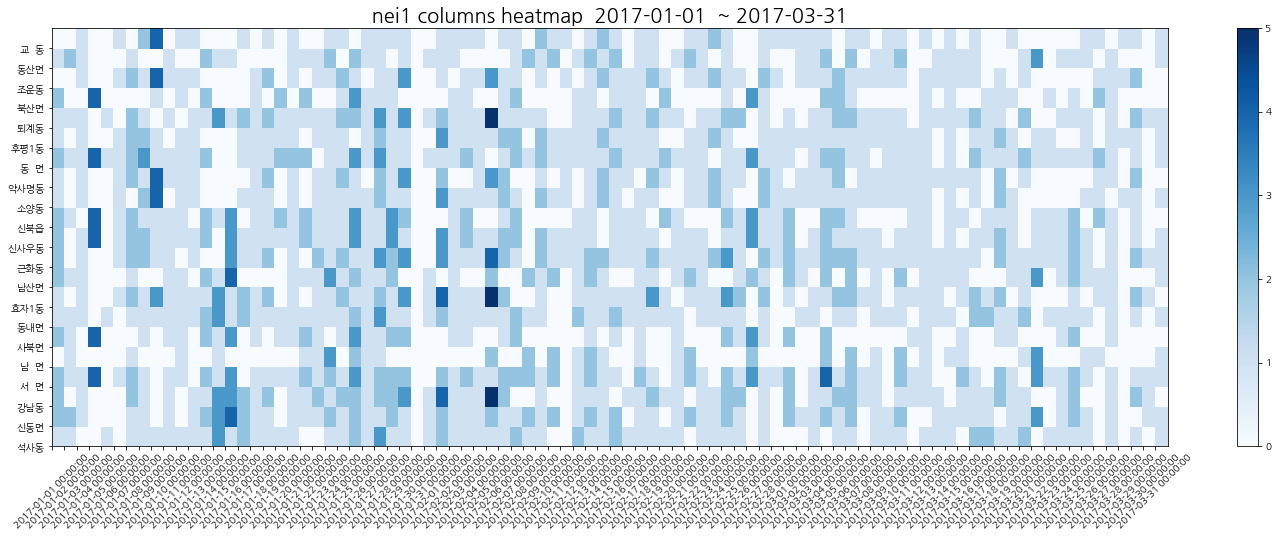

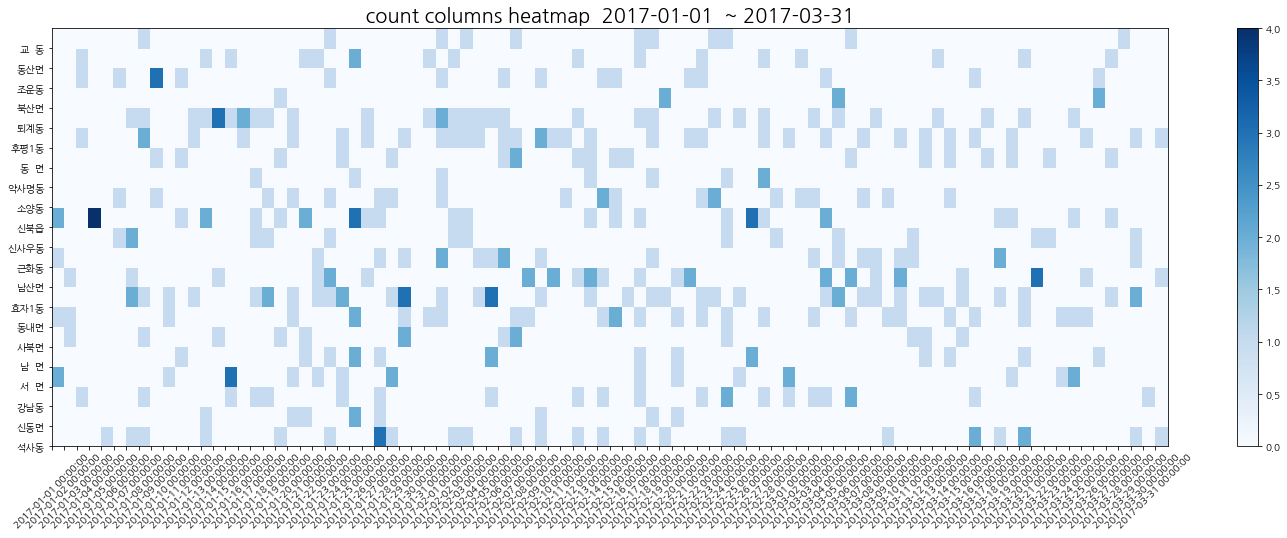

In [49]:
y_df = year_df_max(data , 2017)
get_col_heatmap_test(y_df, 'nei1' , 2017)
get_col_heatmap_test(y_df, 'count' , 2017)

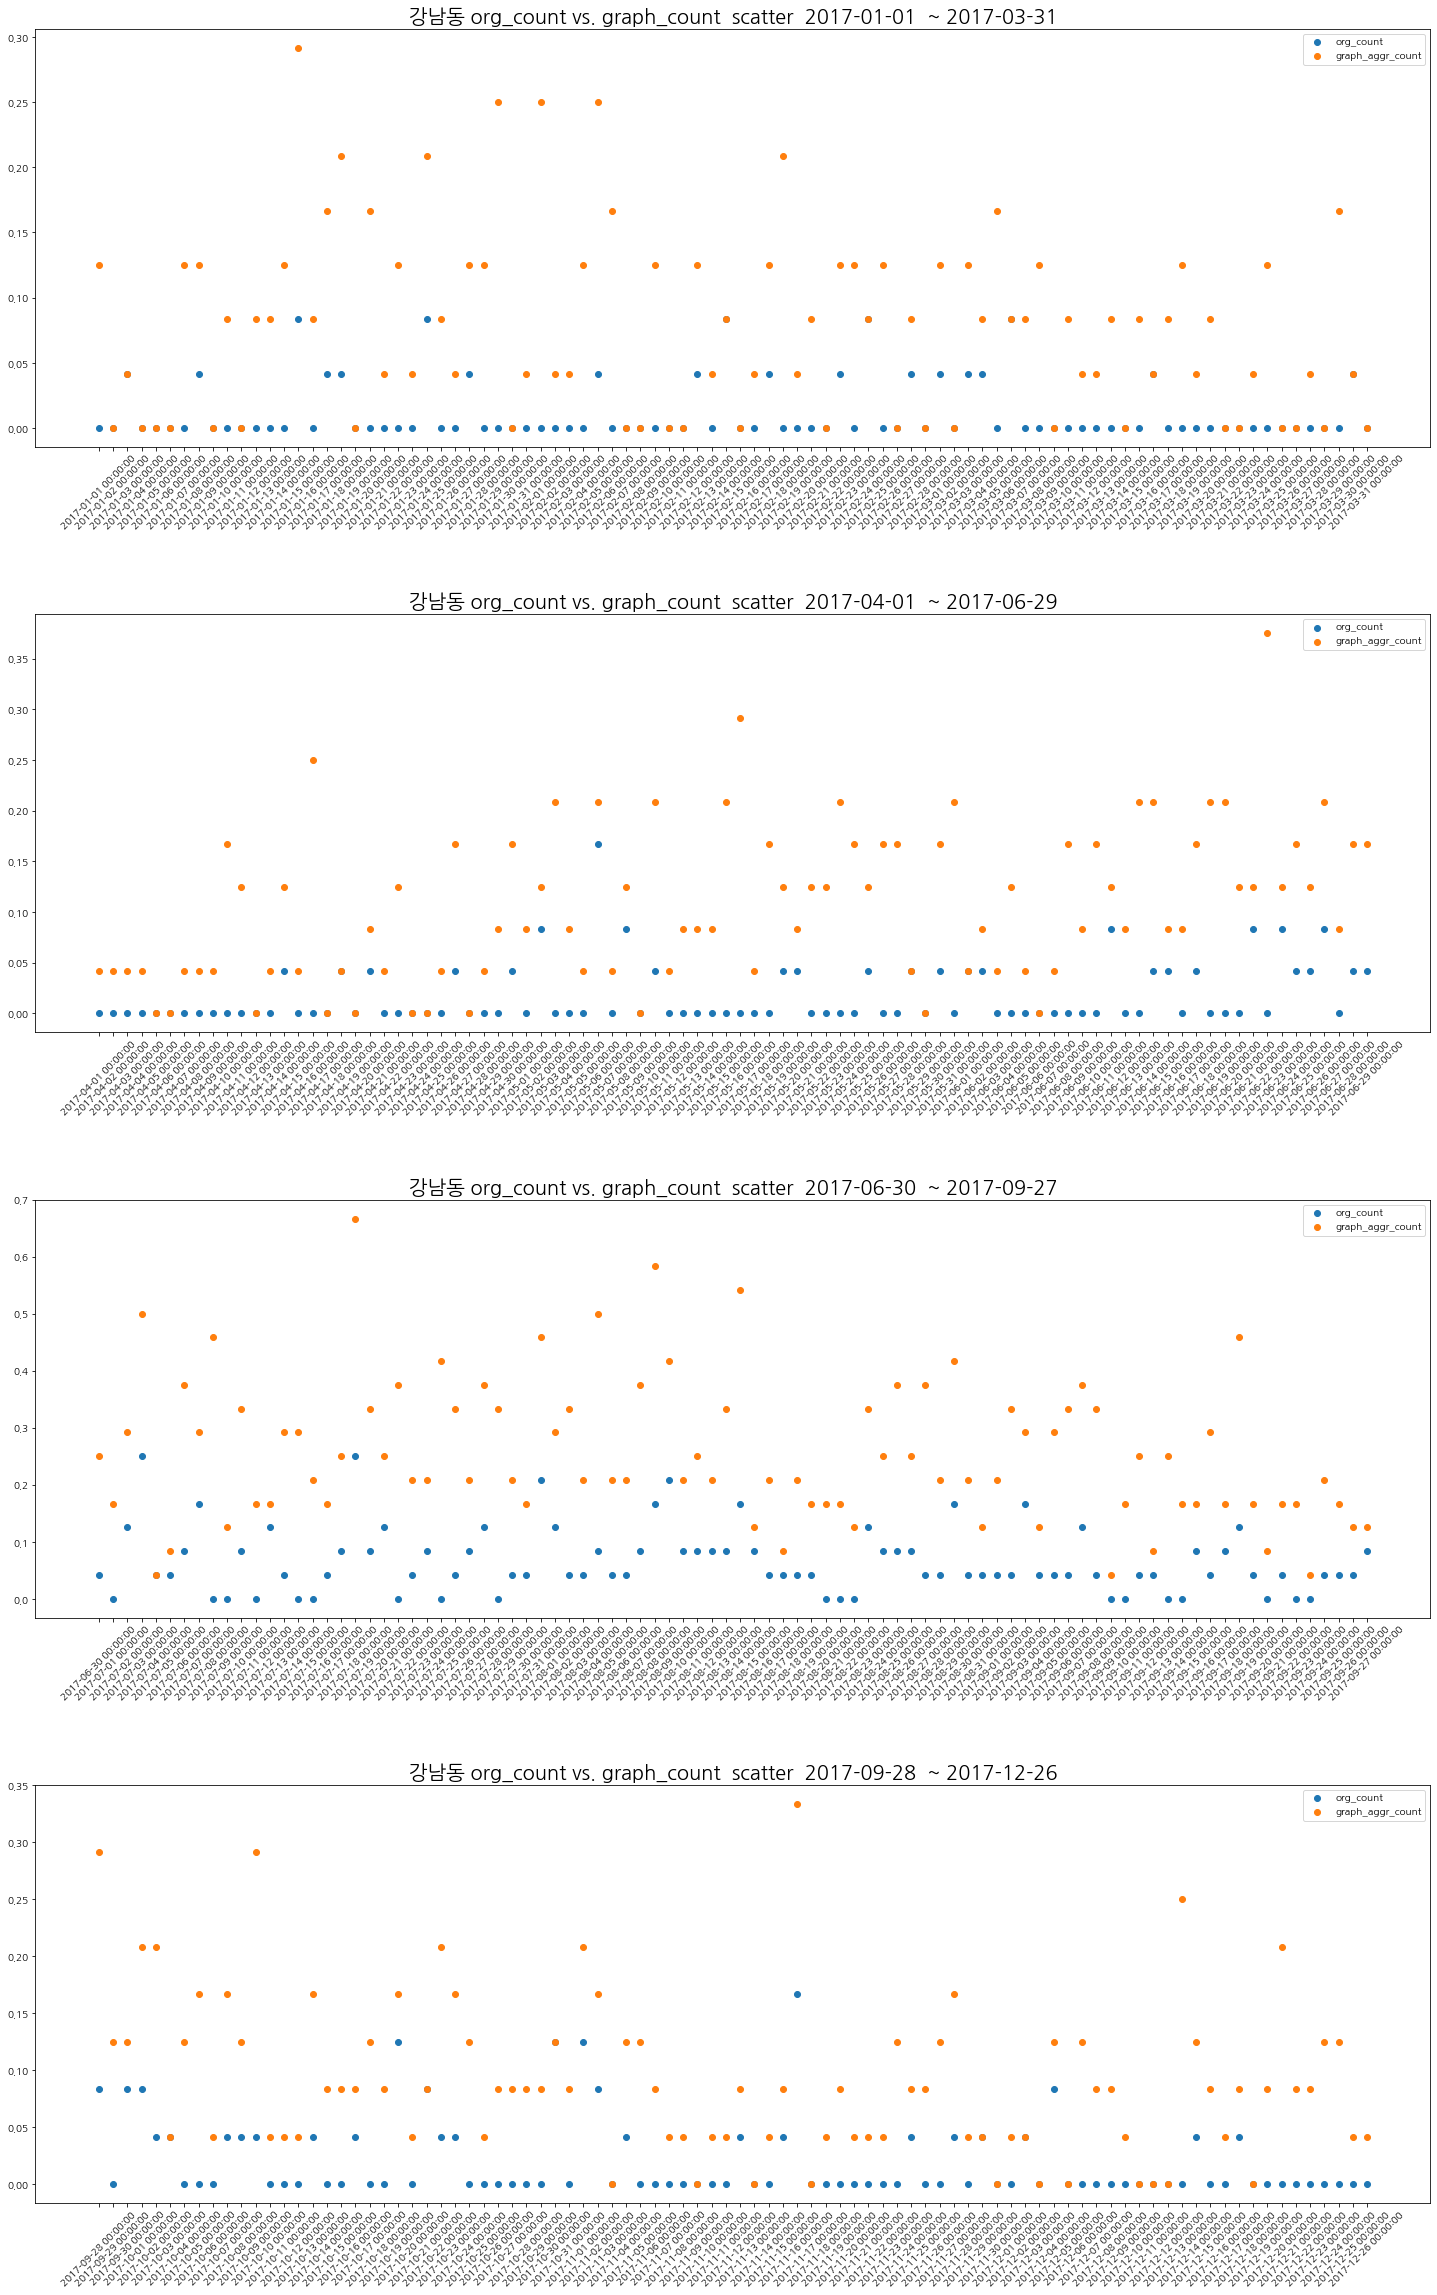

In [50]:
y_df = year_df_mean(data , 2017)
get_col_scatter(y_df ,'강남동', 2017)


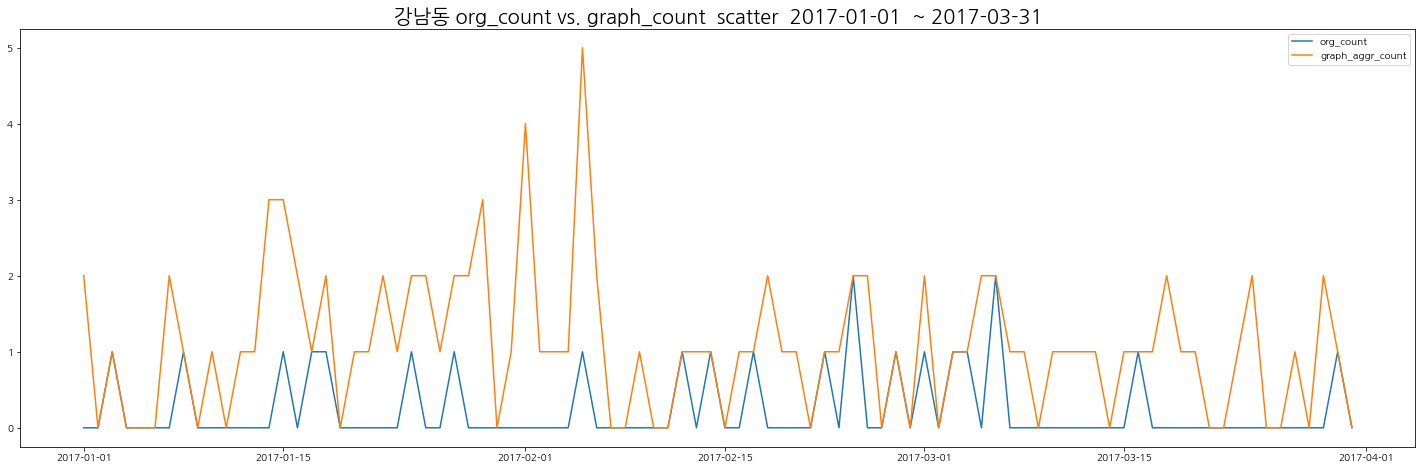

In [51]:
y_df = year_df_max(data , 2017)
get_col_plot(y_df ,'강남동', 2017)
